In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [3]:
movies = pd.read_csv(
    r"C:\Users\MALAY\ds_ml_ai\ml\unsupervised_machine_learning\datasets\ml-1m\movies.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["movie_id", "title", "genres"]
)

movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings = pd.read_csv(
    r"C:\Users\MALAY\ds_ml_ai\ml\unsupervised_machine_learning\datasets\ml-1m\ratings.dat",
    sep="::",
    engine="python",
    encoding="latin-1",
    names=["user_id", "movie_id", "rating", "timestamp"]
)

ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
movie_stats = ratings.groupby("movie_id").agg(
    avg_rating=("rating", "mean"),
    rating_count=("rating", "count")
).reset_index()

movie_stats.head()

,movie_id,avg_rating,rating_count
0,1,4.146846,2077
1,2,3.201141,701
2,3,3.016736,478
3,4,2.729412,170
4,5,3.006757,296


In [7]:
movie_data = movies.merge(
    movie_stats,
    on="movie_id"
)
movie_data.head()

,movie_id,title,genres,avg_rating,rating_count
0,1,Toy Story (1995),Animation|Children's|Comedy,4.146846,2077
1,2,Jumanji (1995),Adventure|Children's|Fantasy,3.201141,701
2,3,Grumpier Old Men (1995),Comedy|Romance,3.016736,478
3,4,Waiting to Exhale (1995),Comedy|Drama,2.729412,170
4,5,Father of the Bride Part II (1995),Comedy,3.006757,296


In [8]:
genres = movie_data["genres"].str.get_dummies(sep="|")
genres.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
X=pd.concat(
    [
        genres,
        movie_data[["avg_rating","rating_count"]]
    ],
    axis=1
)
X.head()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,rating_count
0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,4.146846,2077
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,3.201141,701
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,3.016736,478
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,2.729412,170
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,3.006757,296


In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
inertia = []
k_range = range(2,11)

for k in k_range:
    kmeans=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

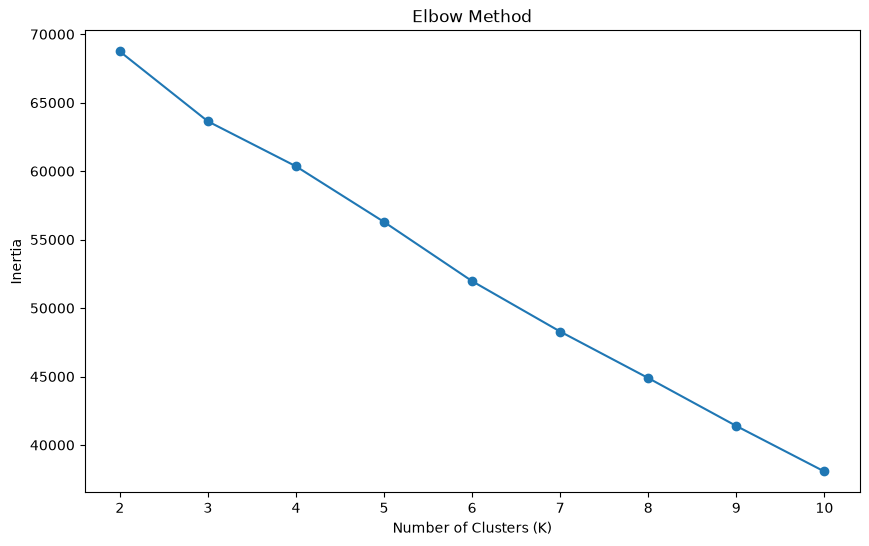

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(
    k_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [15]:
movie_data["cluster"] = clusters

In [16]:
movie_data[
    ["title", "genres", "avg_rating", "rating_count", "cluster"]
].head(20)

,title,genres,avg_rating,rating_count,cluster
0,Toy Story (1995),Animation|Children's|Comedy,4.146846,2077,1
1,Jumanji (1995),Adventure|Children's|Fantasy,3.201141,701,4
2,Grumpier Old Men (1995),Comedy|Romance,3.016736,478,2
3,Waiting to Exhale (1995),Comedy|Drama,2.729412,170,2
4,Father of the Bride Part II (1995),Comedy,3.006757,296,2
5,Heat (1995),Action|Crime|Thriller,3.878723,940,3
6,Sabrina (1995),Comedy|Romance,3.410480,458,2
7,Tom and Huck (1995),Adventure|Children's,3.014706,68,3
8,Sudden Death (1995),Action,2.656863,102,3
9,GoldenEye (1995),Action|Adventure|Thriller,3.540541,888,3


In [17]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.14485152651504324


In [18]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [19]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = clusters

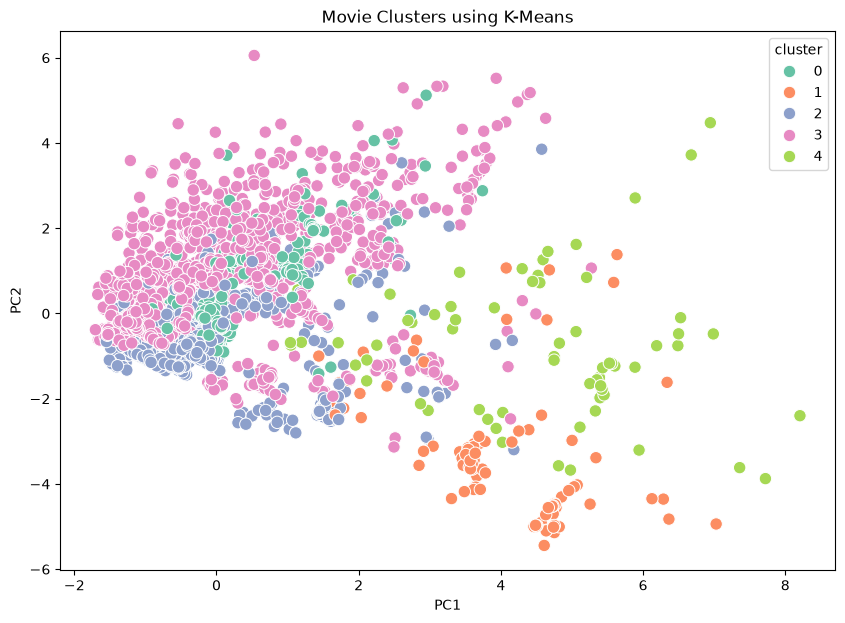

In [20]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=80
)

plt.title("Movie Clusters using K-Means")
plt.show()

In [21]:
kmeans.fit_predict()

TypeError: _BaseKMeans.fit_predict() missing 1 required positional argument: 'X'

In [22]:
movie_data["cluster"].value_counts()

cluster
3    2130
2    1071
0     338
1     100
4      67
Name: count, dtype: int64

In [23]:
cluster_genres = genres.copy()

cluster_genres["cluster"] = clusters

cluster_genres.groupby("cluster").mean()

,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
cluster,,,,,,,,,,,,,,,,,,
0,0.071006,0.020710,0.000000,0.002959,0.121302,0.017751,0.000000,0.032544,0.00,0.002959,1.00,0.005917,0.017751,0.008876,0.168639,0.174556,0.000000,0.000000
1,0.030000,0.110000,1.000000,0.790000,0.240000,0.000000,0.000000,0.000000,0.01,0.010000,0.01,0.320000,0.010000,0.040000,0.080000,0.040000,0.010000,0.000000
2,0.050420,0.033613,0.000000,0.062558,0.999066,0.021475,0.003735,0.193277,0.00,0.000934,0.00,0.030812,0.010271,0.182073,0.024276,0.021475,0.016807,0.015873
3,0.187324,0.090141,0.000000,0.030986,0.004225,0.080282,0.049765,0.594366,0.00,0.019249,0.00,0.021127,0.040376,0.117371,0.079812,0.186854,0.056808,0.023474
4,0.223881,0.522388,0.074627,0.552239,0.283582,0.014925,0.000000,0.134328,1.00,0.000000,0.00,0.014925,0.000000,0.104478,0.194030,0.014925,0.014925,0.000000


In [24]:
for cluster in sorted(movie_data["cluster"].unique()):

    print("\nCLUSTER:", cluster)

    display(
        movie_data[
            movie_data["cluster"] == cluster
        ][
            ["title", "genres", "avg_rating"]
        ].head(10)
    )


CLUSTER: 0


,title,genres,avg_rating
11,Dracula: Dead and Loving It (1995),Comedy|Horror,2.362500
68,From Dusk Till Dawn (1996),Action|Comedy|Crime|Horror|Thriller,3.156455
146,"Addiction, The (1995)",Horror,3.000000
171,Lord of Illusions (1995),Horror,2.733813
182,"Prophecy, The (1995)",Horror,3.221053
190,Species (1995),Horror|Sci-Fi,2.823636
214,Castle Freak (1995),Horror,1.821429
246,Interview with the Vampire (1994),Drama|Horror,3.524390
266,Mary Shelley's Frankenstein (1994),Drama|Horror,2.897541
302,Relative Fear (1994),Horror|Thriller,3.000000



CLUSTER: 1


,title,genres,avg_rating
0,Toy Story (1995),Animation|Children's|Comedy,4.146846
12,Balto (1995),Animation|Children's,3.262626
47,Pocahontas (1995),Animation|Children's|Musical|Romance,2.976440
232,"Goofy Movie, A (1995)",Animation|Children's|Comedy|Romance,2.875000
237,Gumby: The Movie (1995),Animation|Children's,1.900000
304,"Swan Princess, The (1994)",Animation|Children's,2.888889
354,"Lion King, The (1994)",Animation|Children's|Musical,3.860839
574,Aladdin (1992),Animation|Children's|Comedy|Musical,3.788305
580,Snow White and the Seven Dwarfs (1937),Animation|Children's|Musical,3.845347
581,Beauty and the Beast (1991),Animation|Children's|Musical,3.885849



CLUSTER: 2


,title,genres,avg_rating
2,Grumpier Old Men (1995),Comedy|Romance,3.016736
3,Waiting to Exhale (1995),Comedy|Drama,2.729412
4,Father of the Bride Part II (1995),Comedy,3.006757
6,Sabrina (1995),Comedy|Romance,3.410480
10,"American President, The (1995)",Comedy|Drama|Romance,3.793804
18,Ace Ventura: When Nature Calls (1995),Comedy,2.480720
20,Get Shorty (1995),Action|Comedy|Drama,3.623894
33,Babe (1995),Children's|Comedy|Drama,3.891491
37,It Takes Two (1995),Comedy,2.821429
38,Clueless (1995),Comedy|Romance,3.623348



CLUSTER: 3


,title,genres,avg_rating
5,Heat (1995),Action|Crime|Thriller,3.878723
7,Tom and Huck (1995),Adventure|Children's,3.014706
8,Sudden Death (1995),Action,2.656863
9,GoldenEye (1995),Action|Adventure|Thriller,3.540541
13,Nixon (1995),Drama,3.542484
14,Cutthroat Island (1995),Action|Adventure|Romance,2.458904
15,Casino (1995),Drama|Thriller,3.793255
16,Sense and Sensibility (1995),Drama|Romance,4.027545
17,Four Rooms (1995),Thriller,3.337580
19,Money Train (1995),Action,2.537500



CLUSTER: 4


,title,genres,avg_rating
1,Jumanji (1995),Adventure|Children's|Fantasy,3.201141
54,Kids of the Round Table (1995),Adventure|Children's|Fantasy,2.000000
58,"Indian in the Cupboard, The (1995)",Adventure|Children's|Fantasy,3.212885
121,"NeverEnding Story III, The (1994)",Adventure|Children's|Fantasy,1.989899
240,Heavenly Creatures (1994),Drama|Fantasy|Romance|Thriller,3.865828
251,"Kid in King Arthur's Court, A (1995)",Adventure|Children's|Comedy|Fantasy|Romance,2.423611
253,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,4.453694
308,"Santa Clause, The (1994)",Children's|Comedy|Fantasy,3.191888
357,"Mask, The (1994)",Comedy|Crime|Fantasy,3.279050
544,"Pagemaster, The (1994)",Action|Adventure|Animation|Children's|Fantasy,2.703704
